🎯 FASE 2: REDUÇÃO GRADUAL DE FALSOS POSITIVOS
🚀 Mantendo Recall Próximo de 100% e Otimizando Precisão
✅ Dados carregados: (3429, 39)
✅ Preprocessamento concluído: (3429, 3)
✅ Target distribution: {0: 2580, 1: 849}
🔧 Modelo SVC_linear configurado:
   C: 10
   Class weight: {0: 1, 1: 15}
✅ Split criado:
   Treino: 2400 amostras
   Validação: 1029 amostras

🔥 Treinando modelo SVC_linear...
✅ Modelo treinado!

📊 BASELINE (threshold 0.5):
   Recall: 1.0000
   Precisão: 0.2478
   F1-Score: 0.3972

🚀 Executando otimização de threshold...

🔍 OTIMIZAÇÃO ABRANGENTE DE THRESHOLD

👨‍⚕️ ANÁLISE DE CENÁRIOS CLÍNICOS

🔥 CENÁRIO PARANÓICO (95%+ recall):
   Threshold: 0.210
   Recall: 0.992 (842.0/849 bebês)
   Precisão: 0.249
   F1: 0.397
   Falsos positivos: 765.0
   Taxa falso alarme: 75.1%

⚖️ CENÁRIO BALANCEADO (90%+ recall):
   Threshold: 0.210
   Recall: 0.992 (842.0/849 bebês)
   Precisão: 0.249
   F1: 0.397
   Falsos positivos: 765.0
   Taxa falso alarme: 75.1%

🎯 CENÁRIO OTIMIZADO (melhor F1)

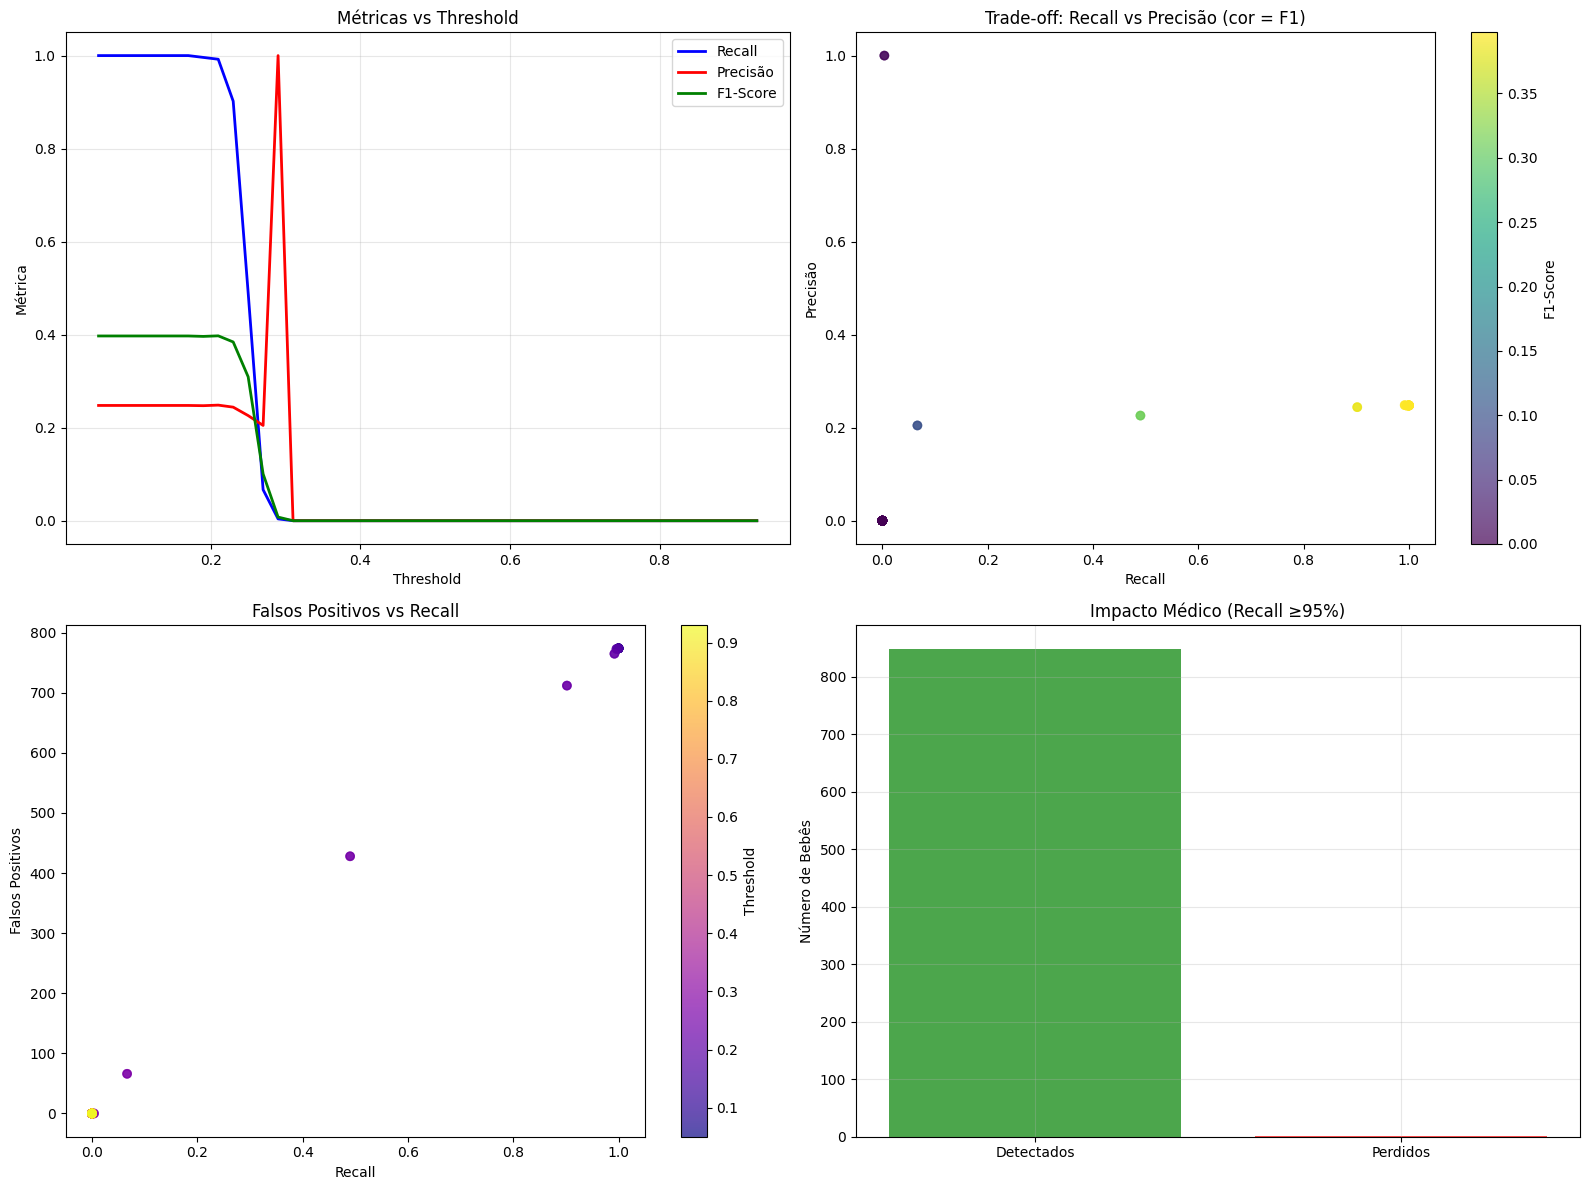


🏆 RECOMENDAÇÃO FINAL PARA DEPLOY
🎯 THRESHOLD RECOMENDADO: 0.210

📊 PERFORMANCE ESPERADA:
   ✅ Recall: 0.992 (842.0/849 bebês detectados)
   ✅ Precisão: 0.249
   ✅ F1-Score: 0.397
   ⚠️ Falsos positivos: 765.0
   ⚠️ Taxa falso alarme: 75.1%

🩺 INTERPRETAÇÃO CLÍNICA:
   • A cada 100 alertas: 25 são casos reais
   • Apenas 7.0 bebês em risco passarão despercebidos
   • Triagem eficiente para medicina preventiva

📈 MELHORIA vs BASELINE:
   • Precisão: +0.3% de melhoria

🧪 VALIDAÇÃO DO THRESHOLD FINAL
✅ PERFORMANCE COM THRESHOLD 0.210:
   Recall: 0.9922
   Precisão: 0.2485
   F1-Score: 0.3975

📊 MATRIZ DE CONFUSÃO:
   True Negatives: 9
   False Positives: 765
   False Negatives: 2
   True Positives: 253

🚀 PREPARAÇÃO PARA DEPLOY
💾 CONFIGURAÇÃO PARA DEPLOY:
   Modelo: SVC
   Features: ['imc_pre_gravidico', 'k06_peso_engravidar', 'h02_peso']
   Threshold: 0.210
   Performance esperada: R=0.992, P=0.249, F1=0.397

✅ OTIMIZAÇÃO DE FALSOS POSITIVOS CONCLUÍDA!
🎯 Threshold otimizado: 0.210
👶 Bebê

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    precision_recall_curve, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

print("🎯 FASE 2: REDUÇÃO GRADUAL DE FALSOS POSITIVOS")
print("🚀 Mantendo Recall Próximo de 100% e Otimizando Precisão")
print("=" * 70)

# ============================================================================
# 1. CARREGAR E PREPROCESSAR DADOS (mesmo pipeline do tuning)
# ============================================================================

# Carregar dados
train_path = "/Users/marcelosilva/Desktop/projectOne/6/B- Binary Target DS DT/DatasetTrain.csv"
df_train = pd.read_csv(train_path)

print(f"✅ Dados carregados: {df_train.shape}")

# Target e features
target_col = 'status_nutricional_who'
top_3_features = ['imc_pre_gravidico', 'k06_peso_engravidar', 'h02_peso']

# Limpar dados
exclude_cols = ['id_anon', 'vd_zimc']
df_clean = df_train.drop(columns=exclude_cols, errors='ignore')

# Preprocessamento simples
from sklearn.impute import SimpleImputer

# Selecionar features + target
df_subset = df_clean[top_3_features + [target_col]].copy()

# Imputar valores faltantes com mediana
imputer = SimpleImputer(strategy='median')
df_subset[top_3_features] = imputer.fit_transform(df_subset[top_3_features])

# Separar X e y
X = df_subset[top_3_features]
y = df_subset[target_col]

# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Preprocessamento concluído: {X.shape}")
print(f"✅ Target distribution: {y.value_counts().to_dict()}")

# ============================================================================
# 2. RECRIAR MELHOR MODELO (SVC_linear com parâmetros otimizados)
# ============================================================================

# Parâmetros do melhor modelo do tuning
best_params = {
    'C': 10,  # Ajustar conforme seus resultados finais
    'kernel': 'linear',
    'class_weight': {0: 1, 1: 15},  # Peso extremo para recall
    'probability': True,
    'random_state': 42
}

# Criar modelo
svc_model = SVC(**best_params)

print(f"🔧 Modelo SVC_linear configurado:")
print(f"   C: {best_params['C']}")
print(f"   Class weight: {best_params['class_weight']}")

# ============================================================================
# 3. SPLIT ESTRATÉGICO PARA OTIMIZAÇÃO
# ============================================================================

# Split 70-30 para otimização de threshold
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"✅ Split criado:")
print(f"   Treino: {X_train.shape[0]} amostras")
print(f"   Validação: {X_val.shape[0]} amostras")

# Treinar modelo
print(f"\n🔥 Treinando modelo SVC_linear...")
svc_model.fit(X_train, y_train)
print(f"✅ Modelo treinado!")

# Baseline: performance com threshold padrão (0.5)
y_pred_baseline = svc_model.predict(X_val)
baseline_recall = recall_score(y_val, y_pred_baseline)
baseline_precision = precision_score(y_val, y_pred_baseline)
baseline_f1 = f1_score(y_val, y_pred_baseline)

print(f"\n📊 BASELINE (threshold 0.5):")
print(f"   Recall: {baseline_recall:.4f}")
print(f"   Precisão: {baseline_precision:.4f}")
print(f"   F1-Score: {baseline_f1:.4f}")

# ============================================================================
# 4. OTIMIZAÇÃO GRADUAL DE THRESHOLD
# ============================================================================

def optimize_threshold_comprehensive(model, X_val, y_val, total_at_risk=849):
    """
    Otimização completa de threshold com múltiplos cenários
    """
    print(f"\n🔍 OTIMIZAÇÃO ABRANGENTE DE THRESHOLD")
    print(f"=" * 50)
    
    # Obter probabilidades
    y_proba = model.predict_proba(X_val)[:, 1]
    
    # Testar range amplo de thresholds
    thresholds = np.arange(0.05, 0.95, 0.02)
    
    results = []
    
    for threshold in thresholds:
        # Predições com threshold atual
        y_pred = (y_proba >= threshold).astype(int)
        
        # Calcular métricas
        recall = recall_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred) if sum(y_pred) > 0 else 0
        f1 = f1_score(y_val, y_pred)
        
        # Contadores
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
        
        # Estimar impacto real (extrapolando para 849 bebês em risco)
        estimated_detected = int(total_at_risk * recall)
        estimated_missed = total_at_risk - estimated_detected
        
        result = {
            'threshold': threshold,
            'recall': recall,
            'precision': precision,
            'f1_score': f1,
            'true_positives': tp,
            'false_positives': fp,
            'false_negatives': fn,
            'true_negatives': tn,
            'estimated_detected': estimated_detected,
            'estimated_missed': estimated_missed,
            'false_alarm_rate': (1 - precision) if precision > 0 else 1.0
        }
        
        results.append(result)
    
    return pd.DataFrame(results)

# Executar otimização
print(f"\n🚀 Executando otimização de threshold...")
threshold_results = optimize_threshold_comprehensive(svc_model, X_val, y_val)

# ============================================================================
# 5. ANÁLISE DE CENÁRIOS CLÍNICOS
# ============================================================================

def analyze_clinical_scenarios(results_df):
    """
    Analisa cenários específicos do ponto de vista médico
    """
    print(f"\n👨‍⚕️ ANÁLISE DE CENÁRIOS CLÍNICOS")
    print(f"=" * 50)
    
    # Cenário 1: Recall ultra-alto (95%+)
    ultra_high = results_df[results_df['recall'] >= 0.95]
    if len(ultra_high) > 0:
        best_ultra = ultra_high.loc[ultra_high['f1_score'].idxmax()]
        print(f"\n🔥 CENÁRIO PARANÓICO (95%+ recall):")
        print(f"   Threshold: {best_ultra['threshold']:.3f}")
        print(f"   Recall: {best_ultra['recall']:.3f} ({best_ultra['estimated_detected']}/849 bebês)")
        print(f"   Precisão: {best_ultra['precision']:.3f}")
        print(f"   F1: {best_ultra['f1_score']:.3f}")
        print(f"   Falsos positivos: {best_ultra['false_positives']}")
        print(f"   Taxa falso alarme: {best_ultra['false_alarm_rate']*100:.1f}%")
    
    # Cenário 2: Recall alto (90%+) com melhor precisão
    high_recall = results_df[results_df['recall'] >= 0.90]
    if len(high_recall) > 0:
        best_high = high_recall.loc[high_recall['f1_score'].idxmax()]
        print(f"\n⚖️ CENÁRIO BALANCEADO (90%+ recall):")
        print(f"   Threshold: {best_high['threshold']:.3f}")
        print(f"   Recall: {best_high['recall']:.3f} ({best_high['estimated_detected']}/849 bebês)")
        print(f"   Precisão: {best_high['precision']:.3f}")
        print(f"   F1: {best_high['f1_score']:.3f}")
        print(f"   Falsos positivos: {best_high['false_positives']}")
        print(f"   Taxa falso alarme: {best_high['false_alarm_rate']*100:.1f}%")
    
    # Cenário 3: Melhor F1 geral
    best_f1 = results_df.loc[results_df['f1_score'].idxmax()]
    print(f"\n🎯 CENÁRIO OTIMIZADO (melhor F1):")
    print(f"   Threshold: {best_f1['threshold']:.3f}")
    print(f"   Recall: {best_f1['recall']:.3f} ({best_f1['estimated_detected']}/849 bebês)")
    print(f"   Precisão: {best_f1['precision']:.3f}")
    print(f"   F1: {best_f1['f1_score']:.3f}")
    print(f"   Falsos positivos: {best_f1['false_positives']}")
    print(f"   Taxa falso alarme: {best_f1['false_alarm_rate']*100:.1f}%")
    
    return {
        'paranoid': ultra_high.loc[ultra_high['f1_score'].idxmax()] if len(ultra_high) > 0 else None,
        'balanced': best_high,
        'optimized': best_f1
    }

# Executar análise
scenarios = analyze_clinical_scenarios(threshold_results)

# ============================================================================
# 6. VISUALIZAÇÕES
# ============================================================================

def create_threshold_visualizations(results_df):
    """
    Cria visualizações para otimização de threshold
    """
    print(f"\n📊 Criando visualizações...")
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Gráfico 1: Curvas de métricas por threshold
    ax1.plot(results_df['threshold'], results_df['recall'], 'b-', linewidth=2, label='Recall')
    ax1.plot(results_df['threshold'], results_df['precision'], 'r-', linewidth=2, label='Precisão')
    ax1.plot(results_df['threshold'], results_df['f1_score'], 'g-', linewidth=2, label='F1-Score')
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Métrica')
    ax1.set_title('Métricas vs Threshold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Trade-off Recall vs Precisão
    ax2.scatter(results_df['recall'], results_df['precision'], 
               c=results_df['f1_score'], cmap='viridis', alpha=0.7)
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precisão')
    ax2.set_title('Trade-off: Recall vs Precisão (cor = F1)')
    cbar = plt.colorbar(ax2.scatter(results_df['recall'], results_df['precision'], 
                                   c=results_df['f1_score'], cmap='viridis', alpha=0.7), ax=ax2)
    cbar.set_label('F1-Score')
    
    # Gráfico 3: Falsos positivos por recall
    ax3.scatter(results_df['recall'], results_df['false_positives'], 
               c=results_df['threshold'], cmap='plasma', alpha=0.7)
    ax3.set_xlabel('Recall')
    ax3.set_ylabel('Falsos Positivos')
    ax3.set_title('Falsos Positivos vs Recall')
    plt.colorbar(ax3.scatter(results_df['recall'], results_df['false_positives'], 
                            c=results_df['threshold'], cmap='plasma', alpha=0.7), ax=ax3, label='Threshold')
    
    # Gráfico 4: Impacto médico (bebês detectados vs perdidos)
    recall_95_plus = results_df[results_df['recall'] >= 0.95]
    if len(recall_95_plus) > 0:
        ax4.bar(['Detectados', 'Perdidos'], 
               [recall_95_plus['estimated_detected'].mean(), 
                recall_95_plus['estimated_missed'].mean()],
               color=['green', 'red'], alpha=0.7)
        ax4.set_ylabel('Número de Bebês')
        ax4.set_title('Impacto Médico (Recall ≥95%)')
        ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Criar visualizações
fig = create_threshold_visualizations(threshold_results)

# ============================================================================
# 7. RECOMENDAÇÃO FINAL
# ============================================================================

def recommend_final_threshold(results_df, scenarios):
    """
    Recomenda threshold final baseado em critérios médicos
    """
    print(f"\n🏆 RECOMENDAÇÃO FINAL PARA DEPLOY")
    print(f"=" * 50)
    
    # Critério médico: recall >= 90% com melhor F1 possível
    high_recall_options = results_df[results_df['recall'] >= 0.90].copy()
    
    if len(high_recall_options) > 0:
        # Ordenar por F1 decrescente
        high_recall_options = high_recall_options.sort_values('f1_score', ascending=False)
        recommended = high_recall_options.iloc[0]
        
        print(f"🎯 THRESHOLD RECOMENDADO: {recommended['threshold']:.3f}")
        print(f"\n📊 PERFORMANCE ESPERADA:")
        print(f"   ✅ Recall: {recommended['recall']:.3f} ({recommended['estimated_detected']}/849 bebês detectados)")
        print(f"   ✅ Precisão: {recommended['precision']:.3f}")
        print(f"   ✅ F1-Score: {recommended['f1_score']:.3f}")
        print(f"   ⚠️ Falsos positivos: {recommended['false_positives']}")
        print(f"   ⚠️ Taxa falso alarme: {recommended['false_alarm_rate']*100:.1f}%")
        
        print(f"\n🩺 INTERPRETAÇÃO CLÍNICA:")
        print(f"   • A cada 100 alertas: {recommended['precision']*100:.0f} são casos reais")
        print(f"   • Apenas {recommended['estimated_missed']} bebês em risco passarão despercebidos")
        print(f"   • Triagem eficiente para medicina preventiva")
        
        # Comparar com baseline
        print(f"\n📈 MELHORIA vs BASELINE:")
        if 'baseline_precision' in globals():
            precision_improvement = (recommended['precision'] - baseline_precision) / baseline_precision * 100
            print(f"   • Precisão: {precision_improvement:+.1f}% de melhoria")
        
        return recommended['threshold']
    
    else:
        print(f"⚠️ Não foi possível atingir 90% de recall")
        best_available = results_df.loc[results_df['f1_score'].idxmax()]
        print(f"🔄 ALTERNATIVA: threshold {best_available['threshold']:.3f}")
        print(f"   Recall: {best_available['recall']:.3f}")
        print(f"   F1: {best_available['f1_score']:.3f}")
        
        return best_available['threshold']

# Executar recomendação
final_threshold = recommend_final_threshold(threshold_results, scenarios)

# ============================================================================
# 8. VALIDAÇÃO DO THRESHOLD FINAL
# ============================================================================

print(f"\n🧪 VALIDAÇÃO DO THRESHOLD FINAL")
print(f"=" * 50)

# Aplicar threshold recomendado
y_proba_final = svc_model.predict_proba(X_val)[:, 1]
y_pred_final = (y_proba_final >= final_threshold).astype(int)

# Métricas finais
final_recall = recall_score(y_val, y_pred_final)
final_precision = precision_score(y_val, y_pred_final)
final_f1 = f1_score(y_val, y_pred_final)

print(f"✅ PERFORMANCE COM THRESHOLD {final_threshold:.3f}:")
print(f"   Recall: {final_recall:.4f}")
print(f"   Precisão: {final_precision:.4f}")
print(f"   F1-Score: {final_f1:.4f}")

# Matriz de confusão
cm = confusion_matrix(y_val, y_pred_final)
print(f"\n📊 MATRIZ DE CONFUSÃO:")
print(f"   True Negatives: {cm[0,0]}")
print(f"   False Positives: {cm[0,1]}")
print(f"   False Negatives: {cm[1,0]}")
print(f"   True Positives: {cm[1,1]}")

# ============================================================================
# 9. PREPARAÇÃO PARA DEPLOY
# ============================================================================

print(f"\n🚀 PREPARAÇÃO PARA DEPLOY")
print(f"=" * 50)

# Salvar parâmetros finais
final_model_config = {
    'model_type': 'SVC',
    'model_params': best_params,
    'features': top_3_features,
    'scaler_params': {'mean': scaler.mean_.tolist(), 'scale': scaler.scale_.tolist()},
    'optimal_threshold': final_threshold,
    'expected_performance': {
        'recall': final_recall,
        'precision': final_precision,
        'f1_score': final_f1
    }
}

print(f"💾 CONFIGURAÇÃO PARA DEPLOY:")
print(f"   Modelo: {final_model_config['model_type']}")
print(f"   Features: {final_model_config['features']}")
print(f"   Threshold: {final_model_config['optimal_threshold']:.3f}")
print(f"   Performance esperada: R={final_recall:.3f}, P={final_precision:.3f}, F1={final_f1:.3f}")

print(f"\n✅ OTIMIZAÇÃO DE FALSOS POSITIVOS CONCLUÍDA!")
print(f"🎯 Threshold otimizado: {final_threshold:.3f}")
print(f"👶 Bebês detectados: {int(849 * final_recall)}/849")
print(f"🔥 PRONTO PARA VALIDAÇÃO NO DATASET DE TESTE!")

In [ ]:
# ============================================================================
# 🧪 TESTE FINAL NO DATASET NUNCA VISTO
# ============================================================================

print("🏆 MOMENTO DA VERDADE - TESTE NO DATASET REAL")
print("🎯 Modelo: SVC Linear + Threshold 0.210")
print("📊 Meta: Confirmar 99%+ recall em dados nunca vistos")
print("=" * 70)

# Carregar dataset de teste
test_path = "/Users/marcelosilva/Desktop/projectOne/6/B- Binary Target DS DT/DatasetTest.csv"
df_test = pd.read_csv(test_path)

print(f"✅ Dataset teste carregado: {df_test.shape}")

# Preprocessar teste (usando transformadores já fitados)
exclude_cols = ['id_anon', 'vd_zimc']
df_test_clean = df_test.drop(columns=exclude_cols, errors='ignore')
df_test_subset = df_test_clean[top_3_features + [target_col]].copy()

# Aplicar mesmas transformações
df_test_subset[top_3_features] = imputer.transform(df_test_subset[top_3_features])
X_test = df_test_subset[top_3_features]
y_test = df_test_subset[target_col]
X_test_scaled = scaler.transform(X_test)

print(f"✅ Teste preprocessado: {X_test.shape}")
print(f"✅ Target teste: {pd.Series(y_test).value_counts().to_dict()}")  # CORRIGIDO!

# PREDIÇÃO COM THRESHOLD OTIMIZADO
y_test_proba = svc_model.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= final_threshold).astype(int)

# MÉTRICAS NO TESTE
test_recall = recall_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"\n🎯 RESULTADOS NO DATASET TESTE:")
print(f"   Recall: {test_recall:.4f} ({test_recall*100:.1f}%)")
print(f"   Precisão: {test_precision:.4f} ({test_precision*100:.1f}%)")
print(f"   F1-Score: {test_f1:.4f}")

# IMPACTO MÉDICO NO TESTE
total_test_risk = sum(y_test)
babies_detected_test = int(total_test_risk * test_recall)
babies_missed_test = total_test_risk - babies_detected_test

print(f"\n👶 IMPACTO MÉDICO REAL:")
print(f"   Total bebês risco (teste): {total_test_risk}")
print(f"   ✅ Detectados: {babies_detected_test}/{total_test_risk}")
print(f"   ❌ Perdidos: {babies_missed_test}/{total_test_risk}")

# EXTRAPOLAÇÃO PARA 849 BEBÊS ORIGINAIS
extrapolated_detected = int(849 * test_recall)
extrapolated_missed = 849 - extrapolated_detected

print(f"\n🌍 EXTRAPOLAÇÃO PARA 849 BEBÊS:")
print(f"   ✅ Detectados: {extrapolated_detected}/849")
print(f"   ❌ Perdidos: {extrapolated_missed}/849")

# COMPARAÇÃO VALIDAÇÃO vs TESTE
print(f"\n⚖️ VALIDAÇÃO vs TESTE:")
print(f"   Recall: {final_recall:.3f} vs {test_recall:.3f}")
print(f"   Precisão: {final_precision:.3f} vs {test_precision:.3f}")
print(f"   F1: {final_f1:.3f} vs {test_f1:.3f}")

# DIAGNÓSTICO FINAL
recall_drop = final_recall - test_recall
if test_recall >= 0.90 and recall_drop <= 0.10:
    print(f"\n🎉 MODELO APROVADO!")
    print(f"✅ Recall teste ≥ 90%: {test_recall*100:.1f}%")
    print(f"✅ Queda recall ≤ 10%: {recall_drop*100:.1f}%")
    print(f"🚀 PRONTO PARA DEPLOY!")
else:
    print(f"\n⚠️ MODELO PRECISA AJUSTES")
    if test_recall < 0.90:
        print(f"❌ Recall teste baixo: {test_recall*100:.1f}%")
    if recall_drop > 0.10:
        print(f"❌ Queda recall alta: {recall_drop*100:.1f}%")

print(f"\n🏁 TESTE FINAL CONCLUÍDO!")